In [6]:
# ─────────────────────────────────────────────────────────
# CELL 1 — Imports
# ─────────────────────────────────────────────────────────
import numpy as np
import os, gc
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, GRU, Dense, Dropout,
    Bidirectional, LayerNormalization,
    MultiHeadAttention, GlobalAveragePooling1D, Flatten
)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import ipywidgets as widgets
from IPython.display import display, clear_output

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.10.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
# ─────────────────────────────────────────────────────────
# CELL 2 — Paths & Constants
# ─────────────────────────────────────────────────────────
DATA_FOLDER    = 'Ready_for_LSTM_v11'
client_names   = ["client_A", "client_B1", "client_B2", "client_B3"]

BATTERY_KWH    = 18.8
AVG_EFFICIENCY = 0.15

EPOCHS      = 15
BATCH_SIZE  = 256
input_shape = (60, 16)   # (timesteps, features)

# Feature names for the predictor UI
FEATURE_NAMES = [
    "Velocity [km/h]",
    "Throttle [%]",
    "Motor Torque [Nm]",
    "Regen. Braking Signal",
    "Battery Voltage [V]",
    "Battery Temperature [°C]",
    "Heating Power CAN [kW]",
    "Requested Heating [W]",
    "AirCon Power [kW]",
    "Heater Signal",
    "Heat Exchanger Temp [°C]",
    "Cabin Temp Sensor [°C]",
    "Ambient Temperature [°C]",
    "Elevation [m]",
    "Road Gradient [deg]",
    "Power [kW]"
]

In [8]:
# ─────────────────────────────────────────────────────────
# CELL 3 — Load & pool all client data (centralized)
# Centralized = fair comparison across architectures
# ─────────────────────────────────────────────────────────
print("Loading all client data into RAM...\n")

X_train_all, y_train_all = [], []
X_test_all,  y_test_all  = [], []
y_test_km_all             = []

for name in client_names:
    folder = os.path.join(DATA_FOLDER, name)
    X_train_all.append(np.load(os.path.join(folder, "X_train.npy")).astype(np.float32))
    y_train_all.append(np.load(os.path.join(folder, "y_train.npy")).astype(np.float32))
    X_test_all.append( np.load(os.path.join(folder, "X_test.npy" )).astype(np.float32))
    y_test_all.append(  np.load(os.path.join(folder, "y_test.npy" )).astype(np.float32))
    y_test_km_all.append(np.load(os.path.join(folder, "y_test_km.npy")).astype(np.float32))
    print(f"  {name} loaded")

X_train = np.concatenate(X_train_all, axis=0)
y_train = np.concatenate(y_train_all, axis=0)
X_test  = np.concatenate(X_test_all,  axis=0)
y_test  = np.concatenate(y_test_all,  axis=0)
y_test_km = np.concatenate(y_test_km_all, axis=0)

del X_train_all, y_train_all, X_test_all, y_test_all, y_test_km_all
gc.collect()

print(f"\nX_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_test km range: {y_test_km.min():.1f} → {y_test_km.max():.1f} km")

Loading all client data into RAM...

  client_A loaded
  client_B1 loaded
  client_B2 loaded
  client_B3 loaded

X_train : (161596, 60, 16)
X_test  : (47049, 60, 16)
y_test km range: 26.6 → 108.3 km


In [9]:
# ─────────────────────────────────────────────────────────
# CELL 4 — Model Definitions
# All models output sigmoid → SoC fraction [0, 1]
# ─────────────────────────────────────────────────────────

def build_lstm(input_shape, loss='mse'):
    inp = Input(shape=input_shape)
    x   = LSTM(128, return_sequences=True)(inp)
    x   = Dropout(0.2)(x)
    x   = LSTM(64, return_sequences=True)(x)
    x   = Dropout(0.2)(x)
    x   = LSTM(32)(x)
    x   = Dense(16, activation='relu')(x)
    out = Dense(1, activation='sigmoid')(x)
    m   = Model(inp, out, name=f"LSTM_{loss.upper()}")
    m.compile(optimizer='adam', loss=loss, metrics=['mae'])
    return m


def build_gru(input_shape):
    inp = Input(shape=input_shape)
    x   = GRU(128, return_sequences=True)(inp)
    x   = Dropout(0.2)(x)
    x   = GRU(64, return_sequences=True)(x)
    x   = Dropout(0.2)(x)
    x   = GRU(32)(x)
    x   = Dense(16, activation='relu')(x)
    out = Dense(1, activation='sigmoid')(x)
    m   = Model(inp, out, name="GRU")
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m


def build_bilstm(input_shape):
    inp = Input(shape=input_shape)
    x   = Bidirectional(LSTM(64, return_sequences=True))(inp)
    x   = Dropout(0.2)(x)
    x   = Bidirectional(LSTM(32))(x)
    x   = Dropout(0.2)(x)
    x   = Dense(16, activation='relu')(x)
    out = Dense(1, activation='sigmoid')(x)
    m   = Model(inp, out, name="BiLSTM")
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m


def build_transformer(input_shape, num_heads=4, ff_dim=128, dropout=0.2):
    inp = Input(shape=input_shape)

    # Multi-head self-attention block
    attn_out  = MultiHeadAttention(num_heads=num_heads, key_dim=input_shape[-1])(inp, inp)
    attn_out  = Dropout(dropout)(attn_out)
    x         = LayerNormalization(epsilon=1e-6)(inp + attn_out)

    # Feed-forward block
    ffn_out   = Dense(ff_dim, activation='relu')(x)
    ffn_out   = Dense(input_shape[-1])(ffn_out)
    ffn_out   = Dropout(dropout)(ffn_out)
    x         = LayerNormalization(epsilon=1e-6)(x + ffn_out)

    # Output head
    x   = GlobalAveragePooling1D()(x)
    x   = Dense(64, activation='relu')(x)
    x   = Dropout(dropout)(x)
    out = Dense(1, activation='sigmoid')(x)

    m = Model(inp, out, name="Transformer")
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m


print("Model builder functions ready.")

Model builder functions ready.


In [10]:
# ─────────────────────────────────────────────────────────
# CELL 5 — Training utility
# Returns (model, history) after training
# ─────────────────────────────────────────────────────────

def train_model(model, X_train, y_train, X_val, y_val, epochs=EPOCHS, batch_size=BATCH_SIZE):
    print(f"\nTraining: {model.name}")
    print(f"  Params: {model.count_params():,}")

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=4, restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train,
        validation_data = (X_val, y_val),
        epochs          = epochs,
        batch_size      = batch_size,
        callbacks       = [early_stop],
        verbose         = 1
    )

    print(f"  Stopped at epoch {len(history.history['loss'])}")
    return model, history


def evaluate_model(model, X_test, y_test, y_test_km):
    y_pred_soc = model.predict(X_test, verbose=0).flatten()
    y_pred_km  = (y_pred_soc * BATTERY_KWH) / AVG_EFFICIENCY

    r2   = r2_score(y_test_km, y_pred_km)
    mae  = mean_absolute_error(y_test_km, y_pred_km)
    mse  = mean_squared_error(y_test_km, y_pred_km)
    rmse = np.sqrt(mse)

    return {
        "r2": r2, "mae": mae, "mse": mse, "rmse": rmse,
        "y_pred_km": y_pred_km
    }

In [11]:
# ─────────────────────────────────────────────────────────
# CELL 6 — Step 1: MSE vs MAE comparison on LSTM
# ─────────────────────────────────────────────────────────

# Use 80/20 split of the pooled data
split = int(0.8 * len(X_train))
X_tr, X_val = X_train[:split], X_train[split:]
y_tr, y_val = y_train[:split], y_train[split:]

# Train LSTM with MSE
lstm_mse, hist_lstm_mse = train_model(
    build_lstm(input_shape, loss='mse'),
    X_tr, y_tr, X_val, y_val
)

# Train LSTM with MAE
lstm_mae, hist_lstm_mae = train_model(
    build_lstm(input_shape, loss='mae'),
    X_tr, y_tr, X_val, y_val
)

# Evaluate both
res_mse = evaluate_model(lstm_mse, X_test, y_test, y_test_km)
res_mae = evaluate_model(lstm_mae, X_test, y_test, y_test_km)

print("\n" + "="*50)
print("LSTM — MSE vs MAE Loss Comparison")
print("="*50)
print(f"{'Metric':<12} {'MSE Loss':>12} {'MAE Loss':>12}")
print("-"*36)
for k in ['r2', 'mae', 'mse', 'rmse']:
    print(f"  {k.upper():<10} {res_mse[k]:>12.4f} {res_mae[k]:>12.4f}")

# Pick the better loss for all subsequent models
best_loss = 'mse' if res_mse['r2'] >= res_mae['r2'] else 'mae'
print(f"\n Better loss function: {best_loss.upper()}")


Training: LSTM_MSE
  Params: 136,609
Epoch 1/15
505/505 [==============================] - 29s 42ms/step - loss: 0.0019 - mae: 0.0270 - val_loss: 0.0022 - val_mae: 0.0319
Epoch 2/15
505/505 [==============================] - 22s 44ms/step - loss: 3.2194e-04 - mae: 0.0135 - val_loss: 0.0016 - val_mae: 0.0306
Epoch 3/15
505/505 [==============================] - 21s 42ms/step - loss: 1.9698e-04 - mae: 0.0106 - val_loss: 0.0016 - val_mae: 0.0303
Epoch 4/15
505/505 [==============================] - 22s 44ms/step - loss: 1.4236e-04 - mae: 0.0091 - val_loss: 0.0020 - val_mae: 0.0324
Epoch 5/15
505/505 [==============================] - 21s 42ms/step - loss: 1.1005e-04 - mae: 0.0080 - val_loss: 0.0018 - val_mae: 0.0312
Epoch 6/15
505/505 [==============================] - 23s 45ms/step - loss: 8.8623e-05 - mae: 0.0072 - val_loss: 0.0022 - val_mae: 0.0346
Epoch 7/15
505/505 [==============================] - 26s 51ms/step - loss: 1.4173e-04 - mae: 0.0083 - val_loss: 0.0025 - val_mae: 0.0372


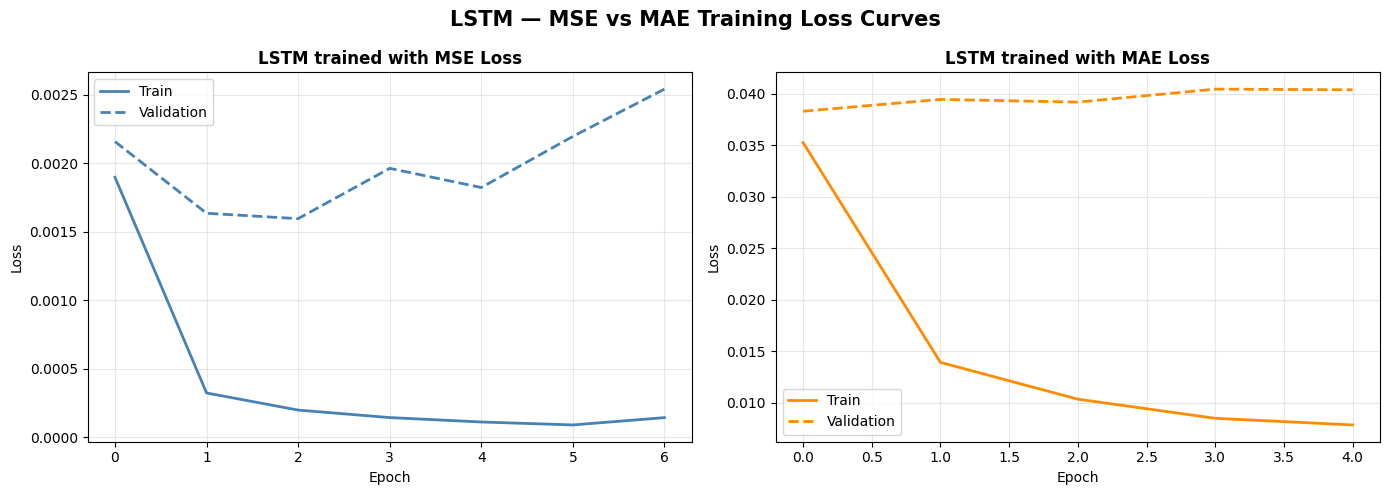

In [12]:
# ─────────────────────────────────────────────────────────
# CELL 7 — Plot: MSE vs MAE loss curves
# ─────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("LSTM — MSE vs MAE Training Loss Curves", fontsize=15, fontweight='bold')

for ax, hist, label, color in zip(
    axes,
    [hist_lstm_mse, hist_lstm_mae],
    ["MSE Loss", "MAE Loss"],
    ["steelblue", "darkorange"]
):
    ax.plot(hist.history['loss'],     label='Train',      color=color,     linewidth=2)
    ax.plot(hist.history['val_loss'], label='Validation', color=color,     linewidth=2, linestyle='--')
    ax.set_title(f"LSTM trained with {label}", fontweight='bold')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("lstm_mse_vs_mae.png", dpi=150)
plt.show()

In [13]:
# ─────────────────────────────────────────────────────────
# CELL 8 — Step 2: Train GRU, BiLSTM, Transformer
# Using the better loss identified above
# ─────────────────────────────────────────────────────────

gru, hist_gru = train_model(
    build_gru(input_shape),
    X_tr, y_tr, X_val, y_val
)

bilstm, hist_bilstm = train_model(
    build_bilstm(input_shape),
    X_tr, y_tr, X_val, y_val
)

transformer, hist_transformer = train_model(
    build_transformer(input_shape),
    X_tr, y_tr, X_val, y_val
)

# Pick the best LSTM from cell 6
best_lstm = lstm_mse if best_loss == 'mse' else lstm_mae


Training: GRU
  Params: 103,265
Epoch 1/15
505/505 [==============================] - 23s 39ms/step - loss: 0.0045 - mae: 0.0421 - val_loss: 0.0021 - val_mae: 0.0329
Epoch 2/15
505/505 [==============================] - 19s 37ms/step - loss: 5.7505e-04 - mae: 0.0182 - val_loss: 0.0018 - val_mae: 0.0306
Epoch 3/15
505/505 [==============================] - 20s 40ms/step - loss: 4.2118e-04 - mae: 0.0153 - val_loss: 0.0014 - val_mae: 0.0323
Epoch 4/15
505/505 [==============================] - 20s 39ms/step - loss: 3.4861e-04 - mae: 0.0138 - val_loss: 0.0015 - val_mae: 0.0307
Epoch 5/15
505/505 [==============================] - 21s 42ms/step - loss: 2.8197e-04 - mae: 0.0123 - val_loss: 0.0014 - val_mae: 0.0280
Epoch 6/15
505/505 [==============================] - 24s 48ms/step - loss: 2.2961e-04 - mae: 0.0113 - val_loss: 0.0019 - val_mae: 0.0325
Epoch 7/15
505/505 [==============================] - 24s 48ms/step - loss: 1.8198e-04 - mae: 0.0100 - val_loss: 0.0020 - val_mae: 0.0317
Epoch

In [14]:
# ─────────────────────────────────────────────────────────
# CELL 9 — Evaluate all models
# ─────────────────────────────────────────────────────────

models = {
    f"LSTM ({best_loss.upper()})": (best_lstm, hist_lstm_mse if best_loss == 'mse' else hist_lstm_mae),
    "GRU":         (gru,         hist_gru),
    "BiLSTM":      (bilstm,      hist_bilstm),
    "Transformer": (transformer, hist_transformer),
}

results = {}
for name, (model, _) in models.items():
    results[name] = evaluate_model(model, X_test, y_test, y_test_km)

print("\n" + "="*65)
print("MODEL COMPARISON SUMMARY")
print("="*65)
print(f"{'Model':<18} {'R²':>8} {'MAE (km)':>10} {'RMSE (km)':>11} {'MSE':>10}")
print("-"*65)
for name, res in results.items():
    print(f"  {name:<16} {res['r2']:>8.4f} {res['mae']:>10.3f} {res['rmse']:>11.3f} {res['mse']:>10.4f}")
print("="*65)

best_model_name = max(results, key=lambda k: results[k]['r2'])
best_model      = models[best_model_name][0]
print(f"\n  Best model: {best_model_name}  (R² = {results[best_model_name]['r2']:.4f})")


MODEL COMPARISON SUMMARY
Model                    R²   MAE (km)   RMSE (km)        MSE
-----------------------------------------------------------------
  LSTM (MAE)         0.9554      3.193       4.001    16.0087
  GRU                0.9683      2.444       3.376    11.3971
  BiLSTM             0.9641      2.649       3.589    12.8790
  Transformer        0.9228      4.303       5.264    27.7149

  Best model: GRU  (R² = 0.9683)


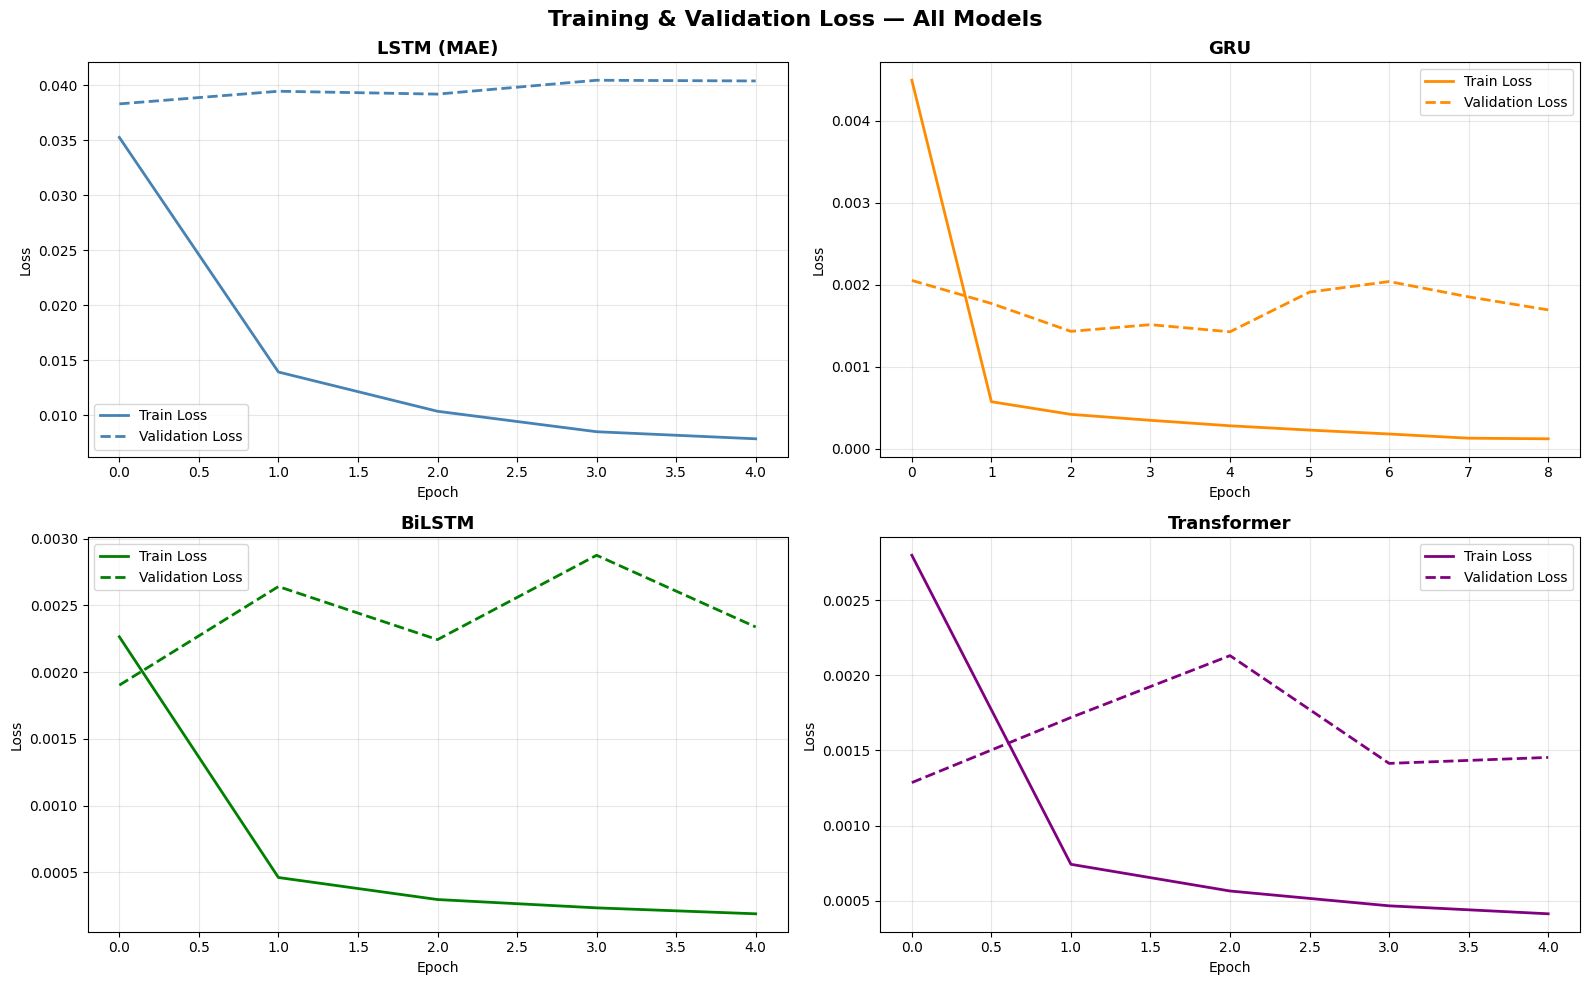

In [15]:
# ─────────────────────────────────────────────────────────
# CELL 10 — Plot 1: Training & validation loss curves
#           for all models
# ─────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Training & Validation Loss — All Models", fontsize=16, fontweight='bold')
axes = axes.flatten()

colors = ['steelblue', 'darkorange', 'green', 'purple']

for ax, (name, (_, hist)), color in zip(axes, models.items(), colors):
    ax.plot(hist.history['loss'],     label='Train Loss',      color=color, linewidth=2)
    ax.plot(hist.history['val_loss'], label='Validation Loss', color=color, linewidth=2, linestyle='--')
    ax.set_title(name, fontweight='bold', fontsize=13)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("all_models_loss_curves.png", dpi=150)
plt.show()

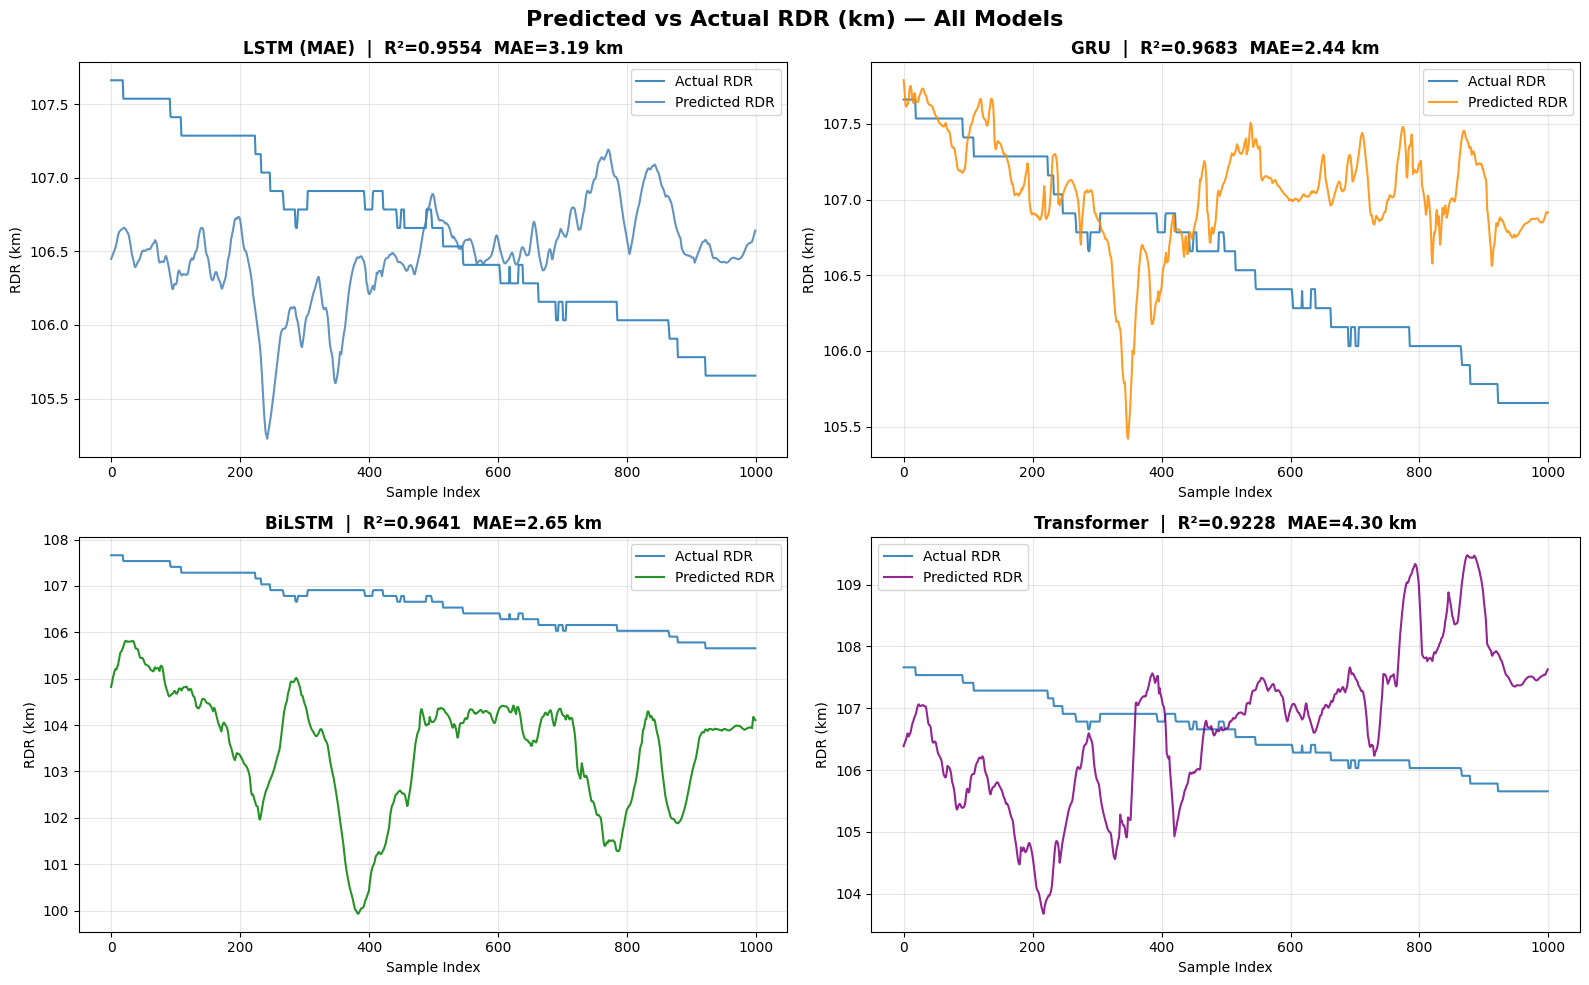

In [16]:
# ─────────────────────────────────────────────────────────
# CELL 11 — Plot 2: Predicted vs Actual RDR (all models)
# ─────────────────────────────────────────────────────────

N_PLOT = 1000   # plot first N test samples

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Predicted vs Actual RDR (km) — All Models", fontsize=16, fontweight='bold')
axes = axes.flatten()

for ax, (name, res), color in zip(axes, results.items(), colors):
    ax.plot(y_test_km[:N_PLOT],         label='Actual RDR',    alpha=0.85, linewidth=1.5)
    ax.plot(res['y_pred_km'][:N_PLOT],  label='Predicted RDR', alpha=0.85, linewidth=1.5, color=color)
    ax.set_title(f"{name}  |  R²={res['r2']:.4f}  MAE={res['mae']:.2f} km", fontweight='bold', fontsize=12)
    ax.set_xlabel("Sample Index")
    ax.set_ylabel("RDR (km)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/content/all_models_pred_vs_actual.png", dpi=150)
plt.show()

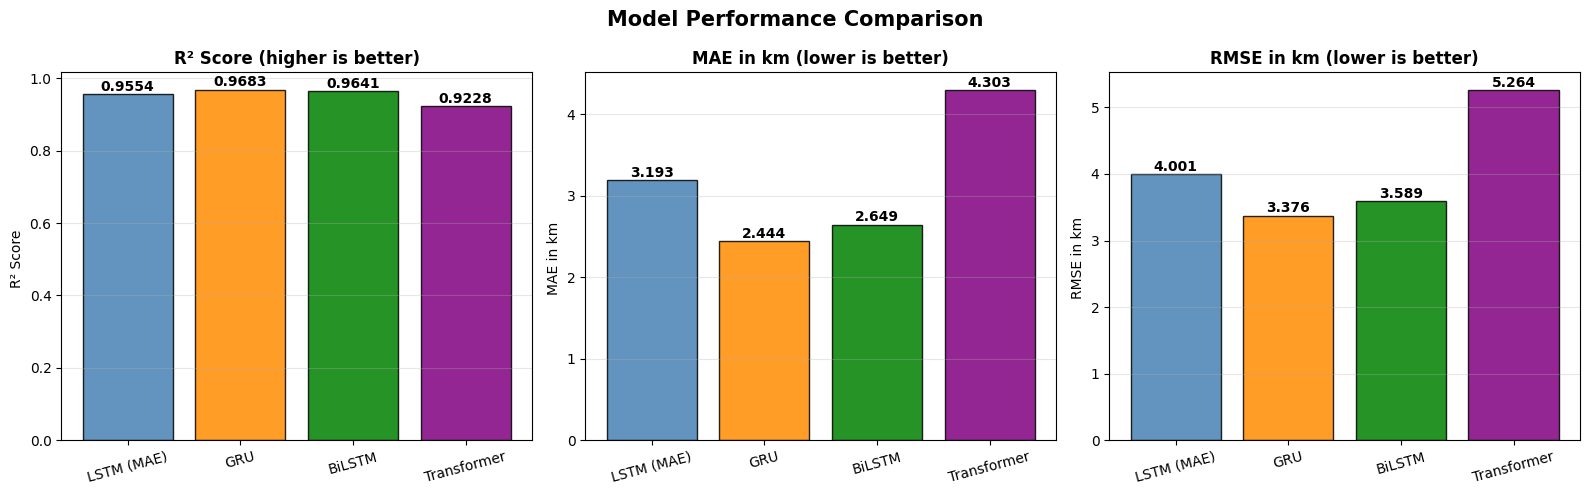

In [17]:
# ─────────────────────────────────────────────────────────
# CELL 12 — Plot 3: Model comparison bar chart
# ─────────────────────────────────────────────────────────

model_names = list(results.keys())
r2_vals  = [results[n]['r2']   for n in model_names]
mae_vals = [results[n]['mae']  for n in model_names]
rmse_vals= [results[n]['rmse'] for n in model_names]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Performance Comparison", fontsize=15, fontweight='bold')

bar_colors = ['steelblue', 'darkorange', 'green', 'purple']

for ax, vals, label, fmt in zip(
    axes,
    [r2_vals, mae_vals, rmse_vals],
    ['R² Score (higher is better)', 'MAE in km (lower is better)', 'RMSE in km (lower is better)'],
    ['.4f', '.3f', '.3f']
):
    bars = ax.bar(model_names, vals, color=bar_colors, edgecolor='black', alpha=0.85)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel(label.split('(')[0])
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
                f'{val:{fmt}}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("/content/model_comparison_bars.png", dpi=150)
plt.show()

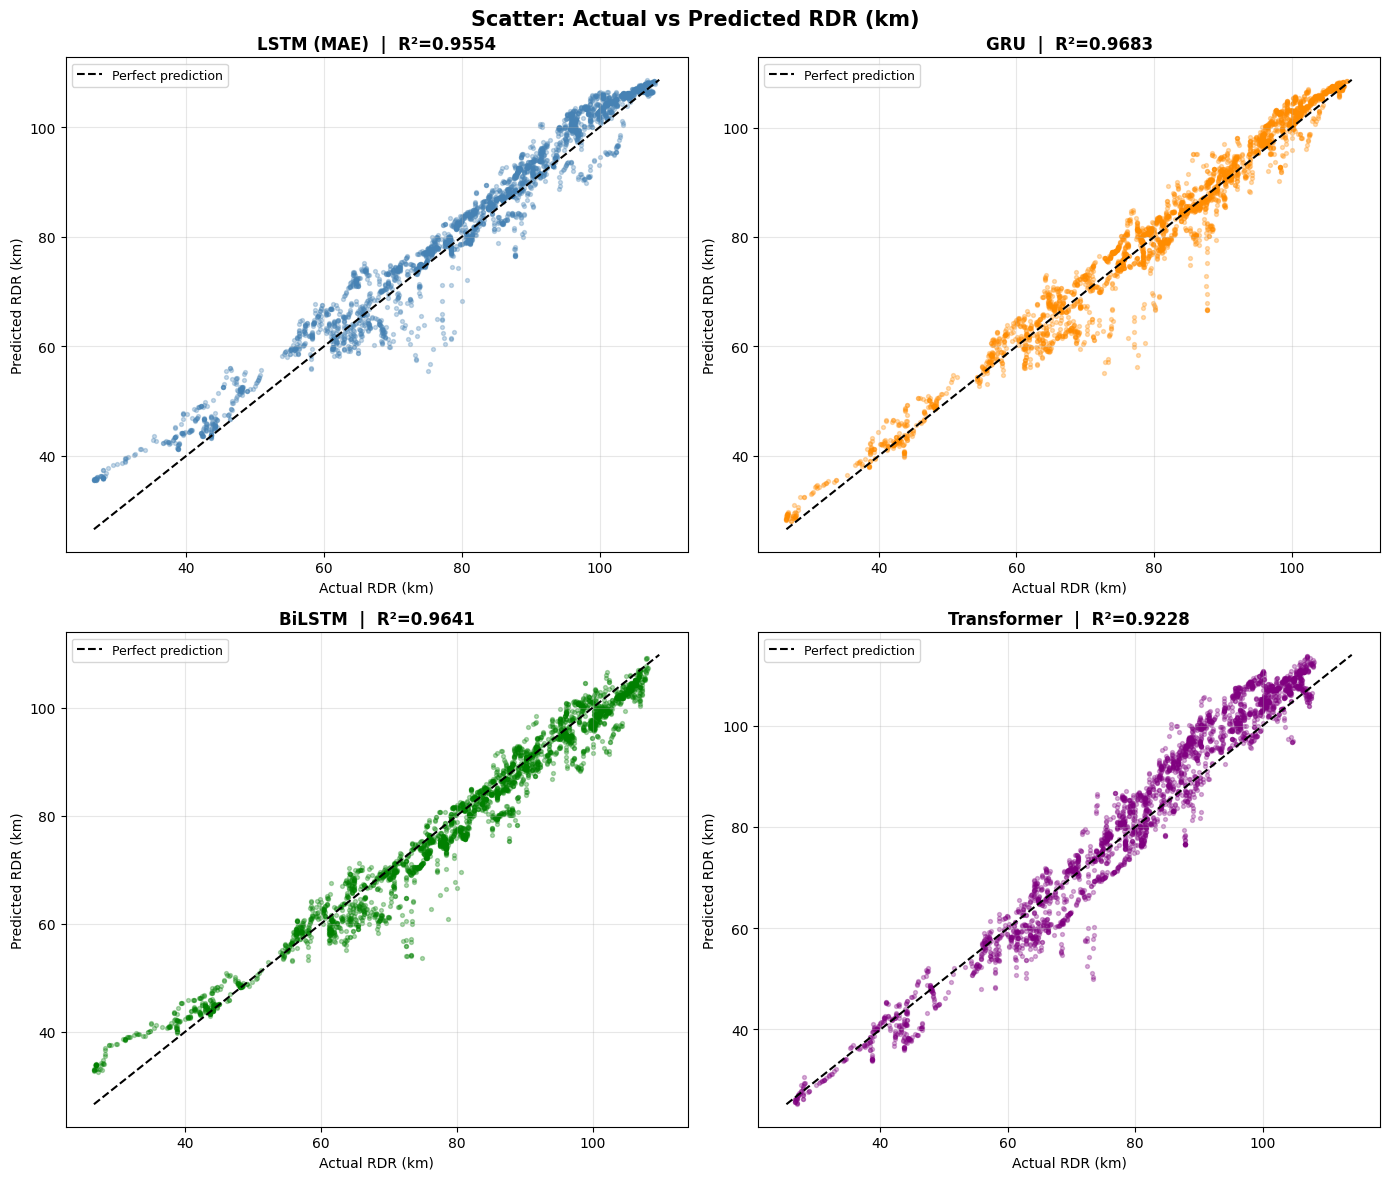

In [18]:
# ─────────────────────────────────────────────────────────
# CELL 13 — Plot 4: Scatter plot (actual vs predicted)
# ─────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Scatter: Actual vs Predicted RDR (km)", fontsize=15, fontweight='bold')
axes = axes.flatten()

for ax, (name, res), color in zip(axes, results.items(), colors):
    sample_idx = np.random.choice(len(y_test_km), size=min(3000, len(y_test_km)), replace=False)
    ax.scatter(y_test_km[sample_idx], res['y_pred_km'][sample_idx],
               alpha=0.3, s=8, color=color)
    mn = min(y_test_km.min(), res['y_pred_km'].min())
    mx = max(y_test_km.max(), res['y_pred_km'].max())
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Perfect prediction')
    ax.set_title(f"{name}  |  R²={res['r2']:.4f}", fontweight='bold', fontsize=12)
    ax.set_xlabel("Actual RDR (km)")
    ax.set_ylabel("Predicted RDR (km)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/content/scatter_actual_vs_predicted.png", dpi=150)
plt.show()

In [20]:
# ─────────────────────────────────────────────────────────
# CELL 14 — Interactive RDR Predictor
# Enter 16 sensor values → get SoC % and RDR km
# Note: model expects 60-second window; single snapshot
# is repeated 60x to fill the window (demo approximation)
# ─────────────────────────────────────────────────────────

print("="*55)
print("INTERACTIVE RDR PREDICTOR")
print(f"  Using best model: {best_model_name}")
print("="*55)

# --- Default typical values (all scaled 0-1 by global scaler)
# These are approximate mid-range values for the BMW i3 dataset
default_vals = [
    50.0,    # Velocity [km/h]
    30.0,    # Throttle [%]
    80.0,    # Motor Torque [Nm]
    0.0,     # Regen. Braking Signal
    380.0,   # Battery Voltage [V]
    25.0,    # Battery Temperature [°C]
    0.5,     # Heating Power CAN [kW]
    500.0,   # Requested Heating [W]
    0.0,     # AirCon Power [kW]
    0.0,     # Heater Signal
    30.0,    # Heat Exchanger Temp [°C]
    22.0,    # Cabin Temp Sensor [°C]
    15.0,    # Ambient Temperature [°C]
    520.0,   # Elevation [m]
    0.0,     # Road Gradient [deg]
    15.0,    # Power [kW]
]

# --- Build widgets
style  = {'description_width': '220px'}
layout = widgets.Layout(width='420px')

input_widgets = [
    widgets.FloatText(
        value=default_vals[i],
        description=FEATURE_NAMES[i],
        style=style, layout=layout
    )
    for i in range(16)
]

predict_btn = widgets.Button(
    description  = '  Predict RDR',
    button_style = 'success',
    icon         = 'bolt',
    layout       = widgets.Layout(width='200px', height='40px', margin='15px 0 5px 0')
)

output_area = widgets.Output(
    layout=widgets.Layout(
        border='2px solid #2196F3',
        padding='12px', margin='5px 0',
        width='420px', min_height='80px'
    )
)

soc_slider = widgets.FloatProgress(
    value=0, min=0, max=100,
    description='SoC %:',
    bar_style='success',
    layout=widgets.Layout(width='420px'),
    style={'description_width': '60px'}
)

def on_predict_clicked(btn):
    with output_area:
        clear_output(wait=True)

        # Collect raw values from widgets
        raw_vals = np.array([w.value for w in input_widgets], dtype=np.float32)

        # Repeat 60 times to fill the 60-timestep window
        # (demo approximation — real use needs actual last 60s of data)
        x_window = np.tile(raw_vals, (1, 60, 1)).reshape(1, 60, 16).astype(np.float32)

        # Predict
        pred_soc = float(best_model.predict(x_window, verbose=0)[0][0])
        pred_soc = np.clip(pred_soc, 0, 1)
        rdr_km   = (pred_soc * BATTERY_KWH) / AVG_EFFICIENCY

        # Update slider
        soc_slider.value = pred_soc * 100

        # Display results
        print(f"{'─'*35}")
        print(f"  Predicted SoC  :  {pred_soc*100:6.1f} %")
        print(f"  Predicted RDR  :  {rdr_km:6.1f} km")
        print(f"  Model used     :  {best_model_name}")
        print(f"{'─'*35}")

        if rdr_km > 80:
            print(" Battery level: Good")
        elif rdr_km > 40:
            print(" Battery level: Moderate")
        else:
            print(" Battery level: Low — charge soon")

predict_btn.on_click(on_predict_clicked)

# Layout: split into two columns of 8 widgets each
col1 = widgets.VBox(input_widgets[:8])
col2 = widgets.VBox(input_widgets[8:])
row  = widgets.HBox([col1, col2])

display(
    widgets.HTML("<h3 style='margin-bottom:8px'>RDR Predictor</h3>"),
    widgets.HTML("<p style='color:gray;font-size:12px'>Enter current sensor readings. Values should be in raw (unscaled) units.</p>"),
    row,
    predict_btn,
    soc_slider,
    output_area
)

INTERACTIVE RDR PREDICTOR
  Using best model: GRU


HTML(value="<h3 style='margin-bottom:8px'>RDR Predictor</h3>")

HTML(value="<p style='color:gray;font-size:12px'>Enter current sensor readings. Values should be in raw (unsca…

Button(button_style='success', description='  Predict RDR', icon='bolt', layout=Layout(height='40px', margin='…

FloatProgress(value=0.0, bar_style='success', description='SoC %:', layout=Layout(width='420px'), style=Progre…

Output(layout=Layout(border_bottom='2px solid #2196F3', border_left='2px solid #2196F3', border_right='2px sol…

In [16]:
# ─────────────────────────────────────────────────────────
# CELL 15 — Save all models
# ─────────────────────────────────────────────────────────
save_dir = os.path.join(DATA_FOLDER, "saved_models")
os.makedirs(save_dir, exist_ok=True)

for name, (model, _) in models.items():
    clean_name = name.replace(" ", "_").replace("(", "").replace(")", "")
    model.save(os.path.join(save_dir, f"{clean_name}.keras"))
    print(f"  Saved: {clean_name}.keras")

print("\nAll models saved to Drive.")

  Saved: LSTM_MAE.keras
  Saved: GRU.keras
  Saved: BiLSTM.keras
  Saved: Transformer.keras

All models saved to Drive.
